<a href="https://colab.research.google.com/github/Pavangoud-git/Credit-Scoring-app/blob/main/ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import Libraries------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [5]:
# Load Dataset------

import pandas as pd
df = pd.read_csv("credit_scoring_dataset_5000_rows.csv")

print(df.head())

   Customer_ID  Age  Annual_Income_INR  Employment_Years Employment_Type  \
0            1   25             639053                 0        Business   
1            2   58             258596                35        Salaried   
2            3   53            1635359                26        Business   
3            4   42            1764594                13   Self-Employed   
4            5   42            1972467                19        Salaried   

  Education Marital_Status Home_Ownership  Loan_Amount  Loan_Term_Months  \
0  Bachelor        Married           Rent       271429                24   
1  Bachelor        Married       Mortgage      1529545                60   
2    Master        Married           Rent      1731240                12   
3  Bachelor        Married            Own      2210566                12   
4  Bachelor        Married            Own      1737952                48   

   Existing_Debt  Debt_To_Income_Ratio  Credit_History_Years  Missed_Payments  \
0    

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 5000 non-null   int64  
 1   Age                         5000 non-null   int64  
 2   Annual_Income_INR           5000 non-null   int64  
 3   Employment_Years            5000 non-null   int64  
 4   Employment_Type             5000 non-null   object 
 5   Education                   5000 non-null   object 
 6   Marital_Status              5000 non-null   object 
 7   Home_Ownership              5000 non-null   object 
 8   Loan_Amount                 5000 non-null   int64  
 9   Loan_Term_Months            5000 non-null   int64  
 10  Existing_Debt               5000 non-null   int64  
 11  Debt_To_Income_Ratio        5000 non-null   float64
 12  Credit_History_Years        5000 non-null   int64  
 13  Missed_Payments             5000 

In [7]:
df.describe()

,Customer_ID,Age,Annual_Income_INR,Employment_Years,Loan_Amount,Loan_Term_Months,Existing_Debt,Debt_To_Income_Ratio,Credit_History_Years,Missed_Payments,Credit_Utilization_Percent,Number_of_Credit_Cards,Number_of_Active_Loans,Savings_Balance,Checking_Balance,Creditworthy_Target
count,5000.000000,5000.000000,5.000000e+03,5000.000000,5.000000e+03,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000
mean,2500.500000,44.936800,1.326321e+06,18.548200,1.514305e+06,47.956800,7.554189e+05,261.957478,14.596800,1.20100,45.442960,3.451200,2.477800,1.503984e+06,506341.482400,0.614000
std,1443.520003,14.182914,6.616986e+05,13.859383,8.562291e+05,24.198381,4.322246e+05,271.089490,8.650665,1.09674,20.059178,2.282161,1.710933,8.654265e+05,288956.231977,0.486879
min,1.000000,21.000000,1.800020e+05,0.000000,5.114200e+04,12.000000,1.900000e+01,5.700000,0.000000,0.00000,1.000000,0.000000,0.000000,9.430000e+02,126.000000,0.000000
25%,1250.750000,33.000000,7.544255e+05,6.000000,7.692575e+05,24.000000,3.771605e+05,104.705000,7.000000,0.00000,31.600000,1.000000,1.000000,7.588502e+05,258614.750000,0.000000
50%,2500.500000,45.000000,1.325376e+06,18.000000,1.521458e+06,48.000000,7.602385e+05,172.225000,15.000000,1.00000,45.400000,3.000000,2.000000,1.515810e+06,510876.500000,1.000000
75%,3750.250000,57.000000,1.891716e+06,30.000000,2.242160e+06,72.000000,1.134394e+06,300.375000,22.000000,2.00000,59.300000,5.000000,4.000000,2.259044e+06,757349.500000,1.000000
max,5000.000000,69.000000,2.499905e+06,45.000000,2.999411e+06,84.000000,1.499920e+06,2249.850000,29.000000,7.00000,100.000000,7.000000,5.000000,2.999727e+06,999377.000000,1.000000


In [8]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Annual_Income_INR,0
Employment_Years,0
Employment_Type,0
Education,0
Marital_Status,0
Home_Ownership,0
Loan_Amount,0
Loan_Term_Months,0


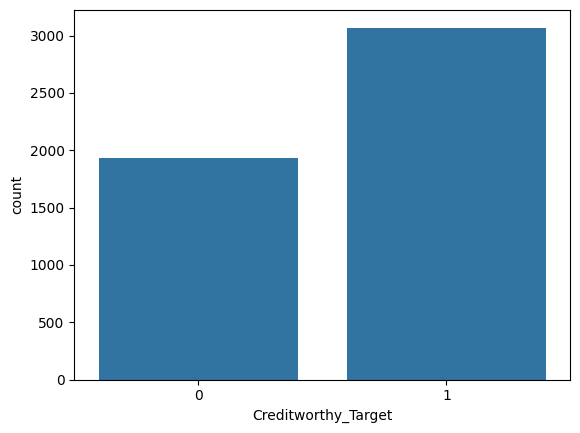

In [9]:
# EDA------
# Target_Distribution

sns.countplot(
    x="Creditworthy_Target",
    data=df
)

plt.show()

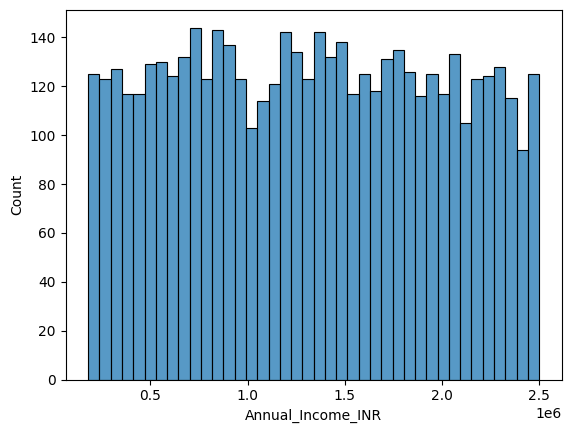

In [10]:
# Income_Distribution

sns.histplot(
    df["Annual_Income_INR"],
    bins=40
)

plt.show()

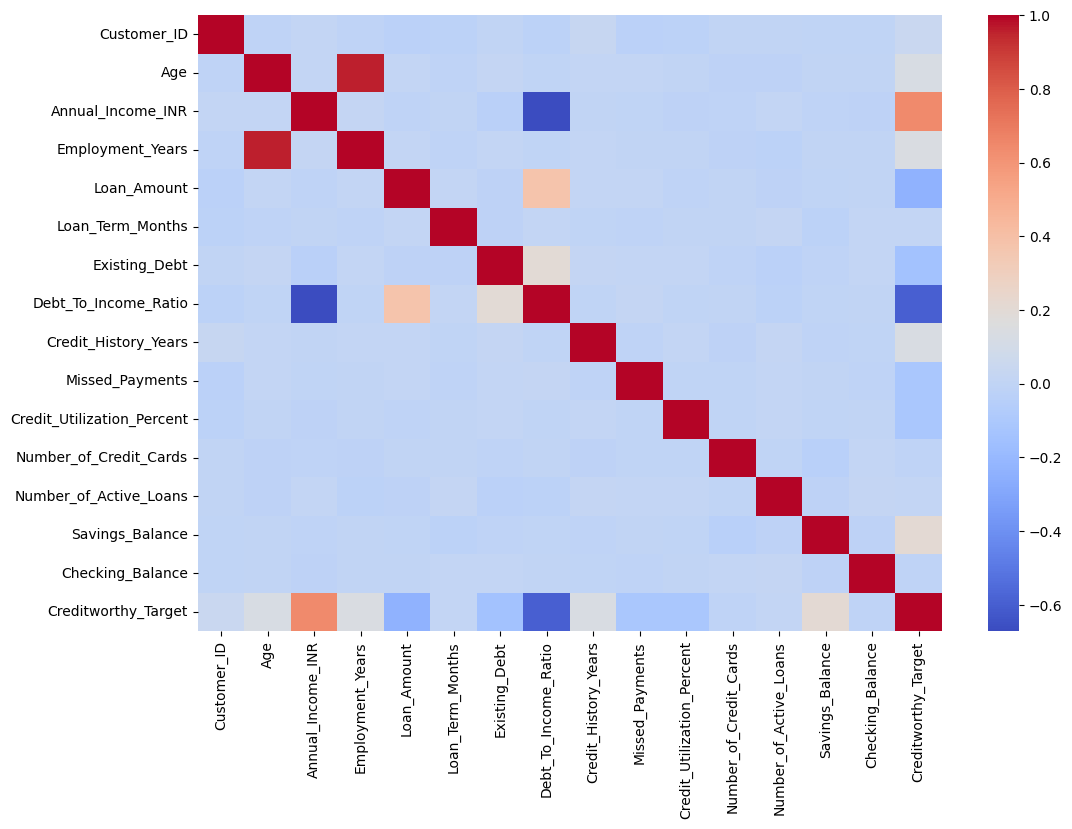

In [11]:
# Correlation_Heatmap----

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()


In [12]:
# Feature Engineering
# Debt_To_Income Category

df["High_DTI"] = np.where(
    df["Debt_To_Income_Ratio"] > 40,1,0)

In [13]:
# Loan_Burden

df["Loan_Per_Month"] = (
    df["Loan_Amount"] /
    df["Loan_Term_Months"]
)

In [14]:
# Savings_Strength

df["Savings_Ratio"] = (
    df["Savings_Balance"] /
    (df["Loan_Amount"] + 1)
)

In [15]:
# Encode Categorical Variables------

le = LabelEncoder()

cat_cols = [
    "Employment_Type",
    "Education",
    "Marital_Status",
    "Home_Ownership"
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [16]:
# Define Features and Target------

X = df.drop(
    "Creditworthy_Target",
    axis=1
)

y = df["Creditworthy_Target"]

In [17]:
# Train-Test Split----------

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
# Build Random Forest Model------

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=12, n_estimators=300, random_state=42)

In [19]:
# Predictions-------

predictions = rf.predict(X_test)

probabilities = rf.predict_proba(X_test)[:,1]

In [20]:
# Model Evaluation------
# Accuracy

accuracy_score(
    y_test,
    predictions
)

0.886

In [21]:
# Precision

precision_score(
    y_test,
    predictions
)

0.8644314868804664

In [22]:
# Recall

recall_score(
    y_test,
    predictions
)

0.9657980456026058

In [23]:
# F1 Score

f1_score(
    y_test,
    predictions
)

0.9123076923076923

In [24]:
# ROC-AUC

roc_auc_score(
    y_test,
    probabilities
)

np.float64(0.9509248789049973)

In [25]:
# Classification Report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.93      0.76      0.84       386
           1       0.86      0.97      0.91       614

    accuracy                           0.89      1000
   macro avg       0.90      0.86      0.87      1000
weighted avg       0.89      0.89      0.88      1000



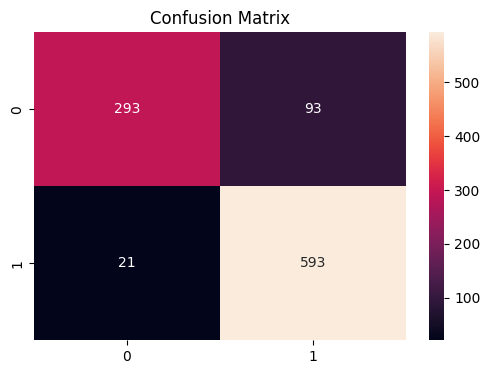

In [26]:
# Confusion Matrix----------

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

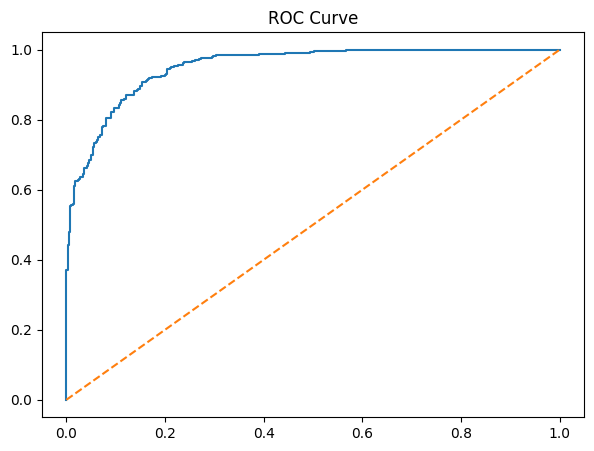

In [27]:
# ROC Curve--------

fpr,tpr,threshold = roc_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.title("ROC Curve")

plt.show()

In [28]:
# Features Importance--------

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

In [29]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [30]:
print(
    importance.head(10)
)

                       Feature  Importance
11        Debt_To_Income_Ratio    0.304085
2            Annual_Income_INR    0.269152
21               Savings_Ratio    0.065396
17             Savings_Balance    0.045739
8                  Loan_Amount    0.036223
12        Credit_History_Years    0.032877
10               Existing_Debt    0.031931
14  Credit_Utilization_Percent    0.031750
20              Loan_Per_Month    0.027836
3             Employment_Years    0.026129


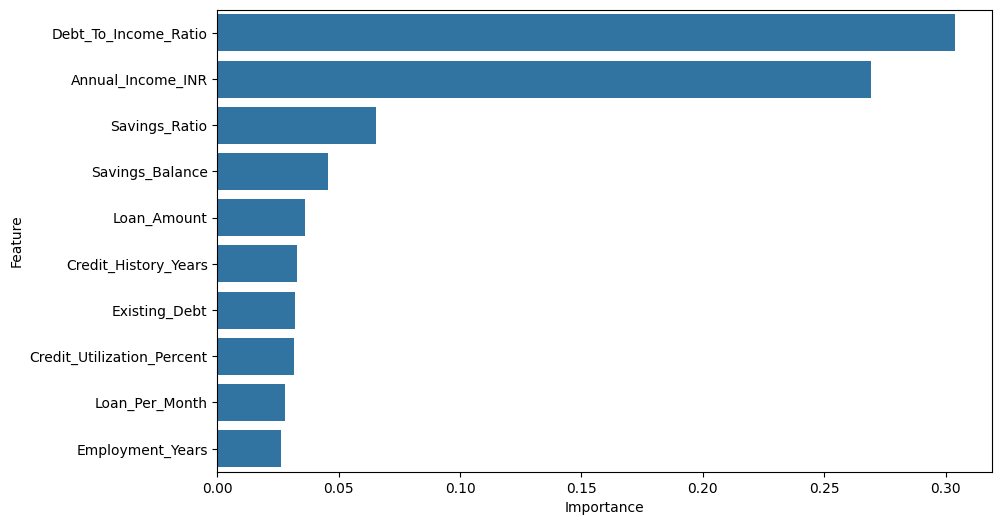

In [31]:
# Visualization

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

In [32]:
# Save Model------

joblib.dump(
    rf,
    "random_forest_model.pkl"
)

['random_forest_model.pkl']

In [33]:
# Predict New Customer--------

sample = X.iloc[[0]]

rf.predict(sample)

array([1])

In [38]:




# Load the model
model = joblib.load("random_forest_model.pkl")

st.title("Credit Scoring Model")

# Note: In a real deployment, you would need inputs for all features used during training
age = st.number_input("Age", value=25)
income = st.number_input("Annual Income", value=500000)
debt = st.number_input("Existing Debt", value=10000)

if st.button("Predict"):
    # The model expects 22 features. Creating a template matching X.columns
    # In practice, you'd collect all 22 or calculate the engineered ones here.
    feature_names = ['Customer_ID', 'Age', 'Annual_Income_INR', 'Employment_Years', 'Employment_Type', 'Education', 'Marital_Status', 'Home_Ownership', 'Loan_Amount', 'Loan_Term_Months', 'Existing_Debt', 'Debt_To_Income_Ratio', 'Credit_History_Years', 'Missed_Payments', 'Credit_Utilization_Percent', 'Number_of_Credit_Cards', 'Number_of_Active_Loans', 'Savings_Balance', 'Checking_Balance', 'High_DTI', 'Loan_Per_Month', 'Savings_Ratio']

    # Create a dummy row with zeros and fill in the user inputs
    data = np.zeros((1, len(feature_names)))
    sample = pd.DataFrame(data, columns=feature_names)
    sample['Age'] = age
    sample['Annual_Income_INR'] = income
    sample['Existing_Debt'] = debt

    prediction = model.predict(sample)

    if prediction[0] == 1:
        st.success("Good Credit Risk")
    else:
        st.error("Bad Credit Risk")

2026-06-19 03:54:25.661 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 03:54:25.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 03:54:25.663 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 03:54:25.666 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 03:54:25.667 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 03:54:25.668 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 03:54:25.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 03:54:25.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar